In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [40]:
x = df[['Pclass','Sex']].copy()
y = df['Survived']

x.loc[:, 'Sex'] = x['Sex'].map({'male': 1, 'female': 0}).astype('str')
x.Sex = x.Sex.astype('float64')


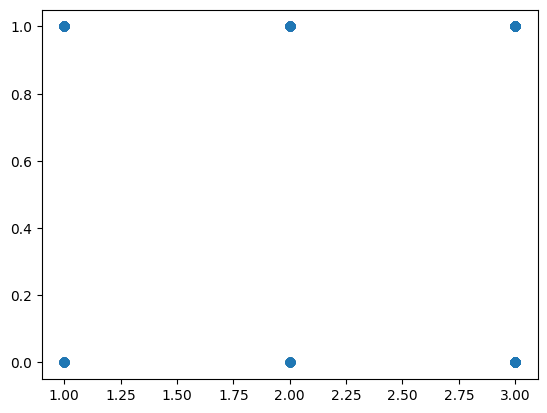

In [41]:
plt.scatter(x['Pclass'], x['Sex'])
plt.show()

In [42]:
np.random.seed(42)

split_lenght = np.round(0.8 * len(x)).astype(int)


x_train = x.iloc[np.random.permutation(len(x))[:split_lenght]]
y_train = y[np.random.permutation(len(y))[:split_lenght]]
x_test = x.iloc[np.random.permutation(len(x))[split_lenght:]]    
y_test = y[np.random.permutation(len(y))[split_lenght:]]


In [43]:
m = np.array([1.0,1.0])
c=1.0
lr =0.1
iterations = 1000

def sigmoid(z):
    return 1/(1+np.exp(-z))

In [44]:
x_train_np = x_train.to_numpy(dtype=float)
y_train_np = y_train.to_numpy(dtype=float)

for _ in range(iterations):
    z = np.dot(x_train_np, m) + c
    preds = sigmoid(z)
    error = preds - y_train_np

    dm = np.mean(x_train_np.T * error, axis=1)
    dc = np.mean(error)

    m = m - lr * dm
    c = c - lr * dc

print(f"m = {m},\nc = {c:.4f}")

m = [-0.01132364  0.00519396],
c = -0.4870


In [45]:
x_test_np = x_test.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=int)

z_test = np.dot(x_test_np, m) + c
probs = sigmoid(z_test)
preds = (probs >= 0.5).astype(int)

for features, p in zip(x_test_np, probs):
    print(f"passenger with features {features} -> {p:.2f} survival probability -> {'survive' if p > 0.5 else 'dead'}")

accuracy = np.mean(preds == y_test_np)
print(f"Test accuracy: {accuracy:.3f}")



passenger with features [1. 0.] -> 0.38 survival probability -> dead
passenger with features [3. 1.] -> 0.37 survival probability -> dead
passenger with features [2. 0.] -> 0.38 survival probability -> dead
passenger with features [2. 1.] -> 0.38 survival probability -> dead
passenger with features [1. 0.] -> 0.38 survival probability -> dead
passenger with features [1. 1.] -> 0.38 survival probability -> dead
passenger with features [1. 1.] -> 0.38 survival probability -> dead
passenger with features [3. 1.] -> 0.37 survival probability -> dead
passenger with features [1. 0.] -> 0.38 survival probability -> dead
passenger with features [3. 0.] -> 0.37 survival probability -> dead
passenger with features [3. 1.] -> 0.37 survival probability -> dead
passenger with features [3. 1.] -> 0.37 survival probability -> dead
passenger with features [3. 1.] -> 0.37 survival probability -> dead
passenger with features [3. 0.] -> 0.37 survival probability -> dead
passenger with features [2. 1.] ->